In [75]:
import sys
sys.path.append("/Users/sujaladhikari/Sujal's Personal/Projects/FedIDS")

In [76]:
import os 
import shutil
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
import torch 
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from Model.model import MLP
from torch.optim import Adam
import utils
from utils import JoinCustomDataset
from sklearn.metrics import classification_report
from federatedlearning import updatefrom_local, weight_averaging, fednova_update_from_local,fednova_weight_averaging
from nids_training import evaluate_model
import matplotlib.pyplot as plt 
import random 

### Setting up the device

In [77]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device
RANDOMSEED = 42
random.seed(RANDOMSEED)
np.random.seed(RANDOMSEED)
torch.manual_seed(RANDOMSEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(RANDOMSEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
### Creating a generator to pass into the data loader 
g = torch.Generator()
g.manual_seed(RANDOMSEED)

### Creating the global model - using the same MLP used for the centralized model 

In [78]:
input_size = 78
hidden_layer = [256, 128,64,8]
num_classes = 2
global_model = MLP(input_size, hidden_layer,num_classes).to(device)
global_model
num_clients = 4

### Creating the Data Configuration and Training Configuration 


In [79]:
batch_size = 64 ## Initially we set up as same as the centralized model 
lr = 1e-2 ## different learning rate
num_rounds = 20 ## 5/.0001 => 50000 rounds 
num_local_epochs = 1
save_interval = 1

In [80]:
### We will be testing the model in the global dataset, which is the same dataset used to test centralized model and federated model
global_dataset = pd.read_csv('../datasets/global_test_dataset.csv')
global_dataset.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_Binary
0,-0.135189,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
1,-0.416792,1.913036,0.019771,0.018355,0.090779,-0.002716,0.419670,-0.258335,0.102476,0.316994,...,0.003116,-0.072992,0.060094,-0.005568,-0.085019,0.356508,-0.155389,0.258998,0.444437,0
2,-0.317572,-0.751546,-0.018182,-0.012594,-0.113059,-0.011345,-0.353239,0.267224,-0.176562,-0.375043,...,0.003061,-0.137113,-0.099480,-0.150381,-0.110743,-0.686650,-0.121376,-0.693794,-0.674594,0
3,-0.410492,-0.353808,-0.010601,-0.008254,-0.077122,-0.006218,-0.201272,-0.216044,-0.219519,-0.172305,...,0.003110,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,1
4,-0.439214,-0.349547,-0.005928,-0.010028,-0.077591,-0.006223,-0.204675,-0.258335,-0.232585,-0.172305,...,0.003116,-0.144686,-0.084676,-0.150402,-0.131186,-0.299561,-0.156966,-0.300753,-0.265660,0


### Global Metrics used to analyze the global fed nova model 

In [81]:
performance_dict, performance_log = dict(), dict()
metric_keys = ['g_train_loss', 'g_test_loss']
performance_dict, performance_log = utils.performance_analyzer(metric_keys)


### Loading each individual client data 

In [82]:
client_directory = '../FederatedAvg/client_data/nids/'
num_clients = 4

In [83]:
client_loaders = [] ## It has four dataloaders for each client 
for index in range(num_clients):
    features_path = f'client_{index}_X_train.csv'
    labels_path = f'client_{index}_y_train.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path) 
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True,generator=g) ## The batch size is 64
    client_loaders.append(dataloader)

### Loading the validation loaders for testing the model's performacen in each epoch in each round 

In [84]:
validation_loaders = []
for index in range(num_clients):
    features_path = f'client_{index}_X_val.csv'
    labels_path = f'client_{index}_y_val.csv'
    features_directory = os.path.join(client_directory, features_path )
    labels_directory = os.path.join(client_directory, labels_path)
    print(features_directory,labels_directory)
    dataset = utils.JoinCustomDataset(features_directory, labels_directory)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size = batch_size, shuffle = True,generator=g)
    validation_loaders.append(dataloader)

../FederatedAvg/client_data/nids/client_0_X_val.csv ../FederatedAvg/client_data/nids/client_0_y_val.csv
../FederatedAvg/client_data/nids/client_1_X_val.csv ../FederatedAvg/client_data/nids/client_1_y_val.csv
../FederatedAvg/client_data/nids/client_2_X_val.csv ../FederatedAvg/client_data/nids/client_2_y_val.csv
../FederatedAvg/client_data/nids/client_3_X_val.csv ../FederatedAvg/client_data/nids/client_3_y_val.csv


### Resuming from the check point 

In [85]:
saving_directory = '../federatedNova/output_nova/'

In [86]:
# Checking if there is already anything going on 
log_path = os.path.join(saving_directory, 'performanance_log.pickle')
if os.path.isfile(log_path):
    performance_log = utils.loading_pickle(log_path)
starting_round = len(performance_log[metric_keys[0]]) ## Check the list of the stored values (g_train), if the value is greaeter thean 0 then the model is already started and doing its job, and if the model crashes then it can continue from where it left!
if starting_round > 0:
    global_model.load_state_dict(torch.load(os.path.join(saving_directory, 'g_r_{}.pth').format(starting_round))) ## The global model takes the weight from where it left 

### Starting the Federated Nova 

In [87]:
global_weights = global_model.state_dict() ## This gives the initial weights of the given model
loss_function = nn.CrossEntropyLoss()
optimization_args = {'lr':lr}

for round in range(starting_round, num_rounds):
    print("Round Number:", round)
    global_model.train()
    client_updates = dict()

    for client_number in range(num_clients):
        print("Client", client_number)
        client_loader = client_loaders[client_number] ## Loading each clients data
        validation_loader = validation_loaders[client_number] ## Loading each clients validation data 
        client_update = fednova_update_from_local(global_model, client_loader, validation_loader, num_local_epochs, optimization_args)

        client_updates.setdefault('delta_weight', list()).append(client_update['delta_weights'])
        client_updates.setdefault('number_samples', list()).append(client_update['num_samples'])
        client_updates.setdefault('tau_k', list()).append(client_update['tau_k'])

        performance_log.setdefault('c_{}_train_loss'.format(client_number), list()).append(client_update['training_loss'])
        ## Train loss of each client using the global model on training data 
        performance_log.setdefault('c_{}_test_loss'.format(client_number), list()).append(client_update['testing_loss'])
    
    
    global_weights = fednova_weight_averaging(global_model, client_updates['delta_weight'], client_updates['number_samples'], client_updates['tau_k'], device, 0.125)
    global_model.load_state_dict(global_weights)

    for client_index in range(num_clients):
        g_train_loss = evaluate_model(global_model, client_loaders[client_index], loss_function, tqdm_desc = 'g_train_loss')
        print(g_train_loss)
        performance_dict['g_train_loss'].update_state(g_train_loss)
        g_test_loss = evaluate_model(global_model, validation_loaders[client_index], loss_function, tqdm_desc='Validation Loss' )
        performance_dict['g_test_loss'].update_state(g_test_loss)
    
    performance_log['g_train_loss'].append(performance_dict['g_train_loss'].result())
    performance_log['g_test_loss'].append(performance_dict['g_test_loss'].result())
    performance_dict['g_train_loss'].reset_state()
    performance_dict['g_test_loss'].reset_state()

## Saving the model 
    for metric in metric_keys:
        print(f"{metric}: {performance_log[metric][-1]}")

    ## Saving the global model 

    if (round + 1)  % save_interval == 0: 
        torch.save(global_model.state_dict(), os.path.join(saving_directory, 'g_r_{}.pth'.format(round+1))) ## Saving the global model's weights in the given directory with the name g_r_1..n.pth
        utils.savein_pickle(log_path,performance_log)  ## Storing the overall value in the pickle form to access it later 


Round Number: 10
Client 0


epoch 1/1: 100%|██████████| 5507/5507 [00:11<00:00, 464.95it/s]


Epoch 1 avg loss: 0.0369


Local Testing Loss: 100%|██████████| 1180/1180 [00:01<00:00, 858.52it/s]


Client 1


...

0.119006984


g_train_loss: 100%|██████████| 48/48 [00:00<00:00, 1011.17it/s]


0.16304563


Validation Loss: 100%|██████████| 11/11 [00:00<00:00, 964.25it/s]

g_train_loss: 0.2526338994503021
g_test_loss: 0.259517103433609


In [99]:
saving_directory = '../models/'
log_path = os.path.join(saving_directory, 'fednova.pickle')
utils.savein_pickle(log_path,global_model)

In [100]:
scaler = StandardScaler()
def batch_maker(dataset):
    dataset = dataset.drop(columns = 'Unnamed: 0', errors='ignore')
    X = dataset.drop(columns = 'Label_Binary')
    X = X.to_numpy()
    y = dataset['Label_Binary']
    y = y.to_numpy()
    X_train , X_test, y_train, y_test = train_test_split(X,y , test_size=0.3, random_state=42)
    X_train = scaler.fit_transform(X_train)
    X_train = torch.tensor(X_train, dtype = torch.float32)
    y_train = torch.tensor(y_train, dtype = torch.long)

    X_test = scaler.transform(X_test)
    X_test = torch.tensor(X_test, dtype = torch.float32)
    y_test = torch.tensor(y_test, dtype = torch.long)

    training_batch = DataLoader(TensorDataset(X_train,y_train), batch_size = 64, shuffle = True,generator=g)
    testing_batch = DataLoader(TensorDataset(X_test,y_test), batch_size=64, shuffle=False,generator=g)
    
    return training_batch,testing_batch 

### Analysis of the global model on each client after the completing all the rounds of training the global model 

In [101]:
siloOne_train, siloOne_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryOne.csv'))
siloTwo_train, siloTwo_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryTwo.csv'))
siloThree_train, siloThree_test= batch_maker(pd.read_csv('../silos_datasets/siloBinaryThree.csv'))
siloFour_train, siloFour_test = batch_maker(pd.read_csv('../silos_datasets/siloBinaryFour.csv'))

In [102]:
criterion = nn.CrossEntropyLoss()
def post_trained_global_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    total = 0 
    correct = 0 
    true_labels = []
    prediction = []

    with torch.no_grad():
        for samples, features in test_loader:
            samples = samples.to(device)
            features = features.to(device)
            output = model(samples)
            loss = criterion(output, features)
            _, predicted = output.max(1)
            prediction.extend(predicted.tolist())
            total += features.size(0)
            test_loss += loss.item()
            correct += predicted.eq(features).sum().item()
            true_labels.extend(features.tolist())

        test_loss = test_loss/len(test_loader.dataset)
        accuracy = 100* correct / total 
    
    return test_loss, accuracy, prediction, true_labels

In [103]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloOne_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0056, Test Accuracy: 80.4811%
              precision    recall  f1-score   support

           0       0.73      0.98      0.83     75551
           1       0.97      0.63      0.76     75477

    accuracy                           0.80    151028
   macro avg       0.85      0.80      0.80    151028
weighted avg       0.85      0.80      0.80    151028



In [104]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloTwo_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0058, Test Accuracy: 88.8429%
              precision    recall  f1-score   support

           0       0.84      0.96      0.90     86566
           1       0.95      0.82      0.88     86705

    accuracy                           0.89    173271
   macro avg       0.90      0.89      0.89    173271
weighted avg       0.90      0.89      0.89    173271



In [105]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloThree_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0018, Test Accuracy: 97.0723%
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      4207
           1       0.95      1.00      0.97      4093

    accuracy                           0.97      8300
   macro avg       0.97      0.97      0.97      8300
weighted avg       0.97      0.97      0.97      8300



In [106]:
test_loss, test_accuracy, predictions, true_labels = post_trained_global_model(global_model, siloFour_test, criterion, device)
print(f" Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}%")
report = classification_report(true_labels, predictions)
print(report)

 Test Loss: 0.0041, Test Accuracy: 94.7531%
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       665
           1       0.93      0.96      0.95       631

    accuracy                           0.95      1296
   macro avg       0.95      0.95      0.95      1296
weighted avg       0.95      0.95      0.95      1296



In [107]:
global_dataset = pd.read_csv('../datasets/global_test_dataset.csv')
X = global_dataset.drop(columns ='Label_Binary')
X = X.to_numpy()
y = global_dataset['Label_Binary']
y = y.to_numpy()
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.long)
global_tuple = TensorDataset(X_tensor,y_tensor)
test_loader = DataLoader(global_tuple, batch_size=batch_size, shuffle=True,generator=g)
global_test_loss, global_accuracy, prediction, true_labels = post_trained_global_model(global_model, test_loader,criterion,device)



In [97]:
print(f"The test loss: {global_test_loss}")
print(f"The accuracy :{global_accuracy}")

The test loss: 0.005524264368091092
The accuracy :85.34693437477537


In [108]:
report = classification_report(true_labels, prediction)
print(report)

              precision    recall  f1-score   support

           0       0.79      0.97      0.87     83474
           1       0.96      0.74      0.83     83474

    accuracy                           0.85    166948
   macro avg       0.87      0.85      0.85    166948
weighted avg       0.87      0.85      0.85    166948



### Plotting model's performance and saving them 

In [111]:
import pickle
with open('../federatedNova/output_nova/performanance_log.pickle', 'rb') as f:
    losses = pickle.load(f)

data = pd.DataFrame(losses)
data.index.name = 'Round'
data = data.reset_index()
data.tail()

,Round,g_train_loss,g_test_loss,c_0_train_loss,c_0_test_loss,c_1_train_loss,c_1_test_loss,c_2_train_loss,c_2_test_loss,c_3_train_loss,c_3_test_loss
15,15,0.279941,0.285479,0.038910,0.039948,0.040291,0.040008,0.029751,0.032429,0.029449,0.178634
16,16,0.260096,0.269121,0.039177,0.039995,0.041950,0.041794,0.021189,0.022348,0.031553,0.237949
17,17,0.260106,0.266110,0.028971,0.030042,0.038697,0.038556,0.017565,0.022282,0.033872,0.037449
18,18,0.247393,0.255383,0.030499,0.030900,0.040323,0.040063,0.018000,0.021174,0.024760,0.019232
19,19,0.252634,0.259517,0.030592,0.031284,0.044883,0.044215,0.017690,0.019703,0.033176,0.094703


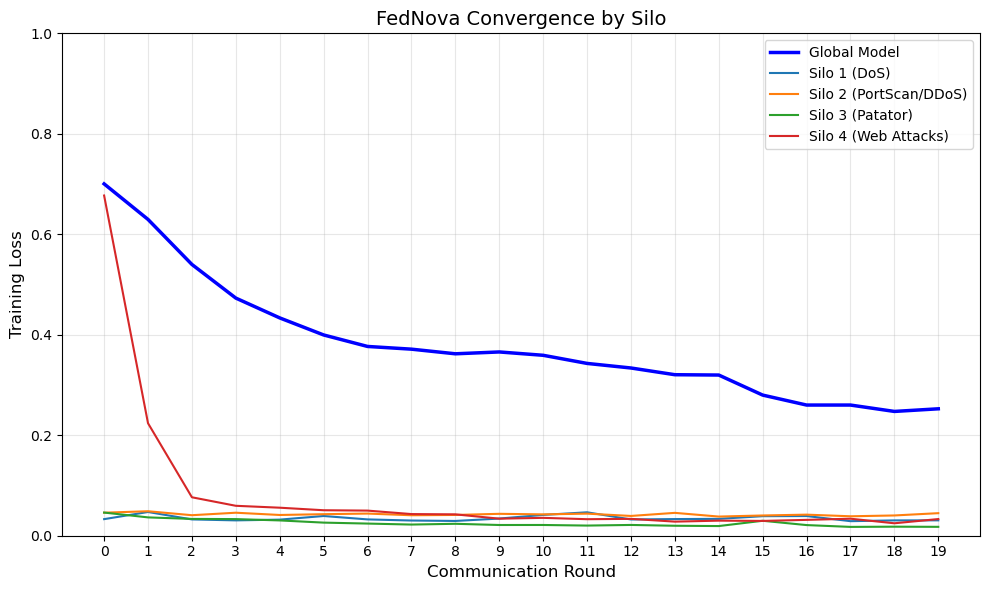

In [130]:
plt.figure(figsize=(10, 6))
plt.plot(data['g_train_loss'], label='Global Model', linewidth=2.5, color='blue')
plt.plot(data['c_0_train_loss'], label='Silo 1 (DoS)', linewidth=1.5)
plt.plot(data['c_1_train_loss'], label='Silo 2 (PortScan/DDoS)', linewidth=1.5)
plt.plot(data['c_2_train_loss'], label='Silo 3 (Patator)', linewidth=1.5)
plt.plot(data['c_3_train_loss'], label='Silo 4 (Web Attacks)', linewidth=1.5)
plt.xticks(np.arange(0,20,1))
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('FedNova Convergence by Silo', fontsize=14)
plt.ylim(0,1)
plt.grid(True, alpha=0.3)  # ← add grid for readability
plt.tight_layout()
plt.legend()
plt.show()

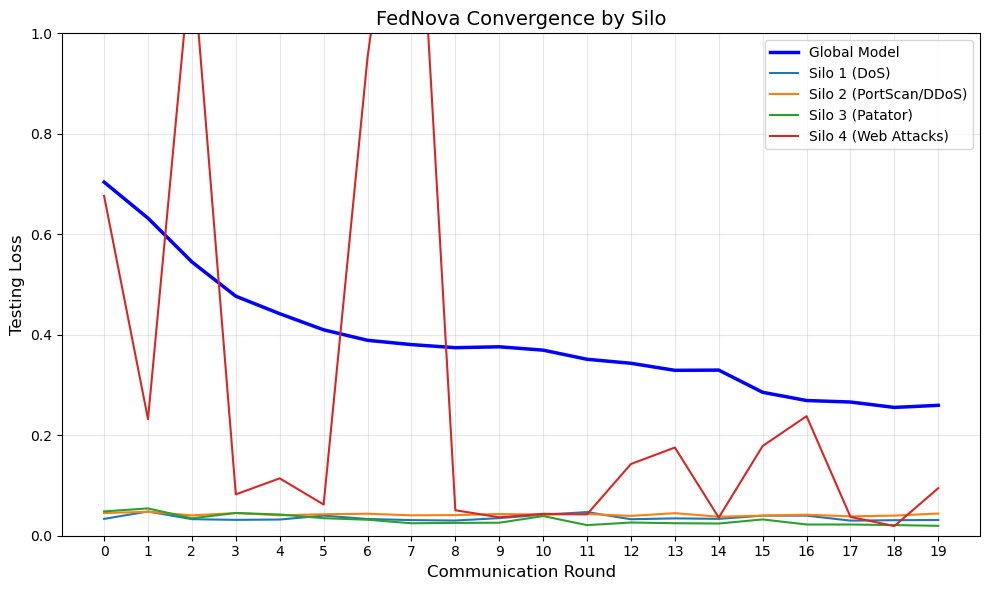

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(data['g_test_loss'], label='Global Model', linewidth=2.5, color='blue')
plt.plot(data['c_0_test_loss'], label='Silo 1 (DoS)', linewidth=1.5)
plt.plot(data['c_1_test_loss'], label='Silo 2 (PortScan/DDoS)', linewidth=1.5)
plt.plot(data['c_2_test_loss'], label='Silo 3 (Patator)', linewidth=1.5)
plt.plot(data['c_3_test_loss'], label='Silo 4 (Web Attacks)', linewidth=1.5)
plt.xticks(np.arange(0,20,1))
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Testing Loss', fontsize=12)
plt.title('FedNova Convergence by Silo', fontsize=14)
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()